# 5. Figures 
This notebook uses the calculated values from `4_Analysis.ipynb` notebook to visualize the core relationships for this project:
* **Analysis 1: Network structure + personality**
* **Analysis 2: Self-similarity vs. ideological similarity**

Input:\
`data/corr.txt` : Matrix of pairwise correlations between network measures and personality traits.\
`data/p_vals.txt` : Matrix of p-values associated with pairwise correlations.\
`data/distances.json` : Pairwise distances (Portrait Divergence) between networks.

Output:\
`figs/corr.png` : Figure 4, Correlations between demographics and network stats.\
`figs/NetSim.png` : Figure 5, Distribution of network distance.\
`figs/NetSim_all_cum.png` : Cumulative distribution, not used in paper.\

In [1]:
# helpful packages
import pandas as pd
import numpy as np
import json

import scipy.stats as sp

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# table creation
from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

In [2]:
# organize variables
politics = ['leftright', # 0=strong Dem, 6 = strong Rep
            'politicalinterest', # 0 = not at all interested, 3= v interested
            'politicalparticipation', # 0 = no protest or petition, 1 = one activity, 2 = both activities
           ]

personality = [
               'TIPI_extraversion',
               'TIPI_agreeableness', 
               'TIPI_conscientiousness',
               'TIPI_emotionalstability', 
               'TIPI_openness'
              ]

demographics = ['age', 
                'female', 
                'education']

# stored network statistics, calculated for each text q
stats = ['giant component', # Connectivity
         'k avg',           # Complexity
         'clustering',
         'density',
         'entropy',         # Hierarchy
         'dissortativity',
         'k std']

# Figure 4: Correlations between demographics and network stats

In [3]:
corr = pd.read_csv('data/corr.txt', index_col=0)
p = pd.read_csv('data/p_vals.txt', index_col=0)

In [4]:
def get_sorted_corr(corr, col_order = list(), row_order = list()):

    # column order
    if not col_order:
        sq = corr.T.dot(corr)
        val, vec = np.linalg.eig(sq)

        # find largest eigenvalue
        index = np.where(val == max(val))[0][0]

        # return largest eigenvector as strength
        vector = vec.T[index]

        order_dict = dict((j,i) for i, j in enumerate(vector))
        newcols = [i for j, i in sorted(order_dict.items())]

        cols = corr.columns.tolist()
        col_order = [cols[i] for i in newcols]

    # row order
    if not row_order:
        sq = corr.dot(corr.T)
        val, vec = np.linalg.eig(sq)

        # find largest eigenvalue
        index = np.where(val == max(val))[0][0]

        # return largest eigenvector as strength
        vector = vec.T[index]

        order_dict = dict((j,i) for i, j in enumerate(vector))
        newrows = [i for j, i in sorted(order_dict.items())]

        rows = corr.index.tolist()
        row_order = [rows[i] for i in newrows][::-1]

    sorted_corr = corr[col_order].reindex(row_order)

    return sorted_corr

In [5]:
sorted_corr = get_sorted_corr(corr)

In [6]:
sorted_p = p.reindex(index=sorted_corr.index, columns=sorted_corr.columns)

In [7]:
masked_corr = pd.DataFrame(np.where(sorted_p > 0.05, 0, sorted_corr),  
                           index=sorted_corr.index, 
                           columns=sorted_corr.columns)

In [8]:
col_dict = {'leftright': 'Party ID (R)',
            'politicalinterest': 'Pol. Interest',
            'politicalparticipation': 'Pol. Participation',
            'TIPI_extraversion' : 'Extraversion',
            'TIPI_agreeableness': 'Agreeableness', 
            'TIPI_conscientiousness': 'Conscientiousness',
            'TIPI_emotionalstability': 'Neuroticism', 
            'TIPI_openness': 'Openness',
            'age': 'Age',
            'female': 'Gender (M)',
            'education': 'Education'
            }

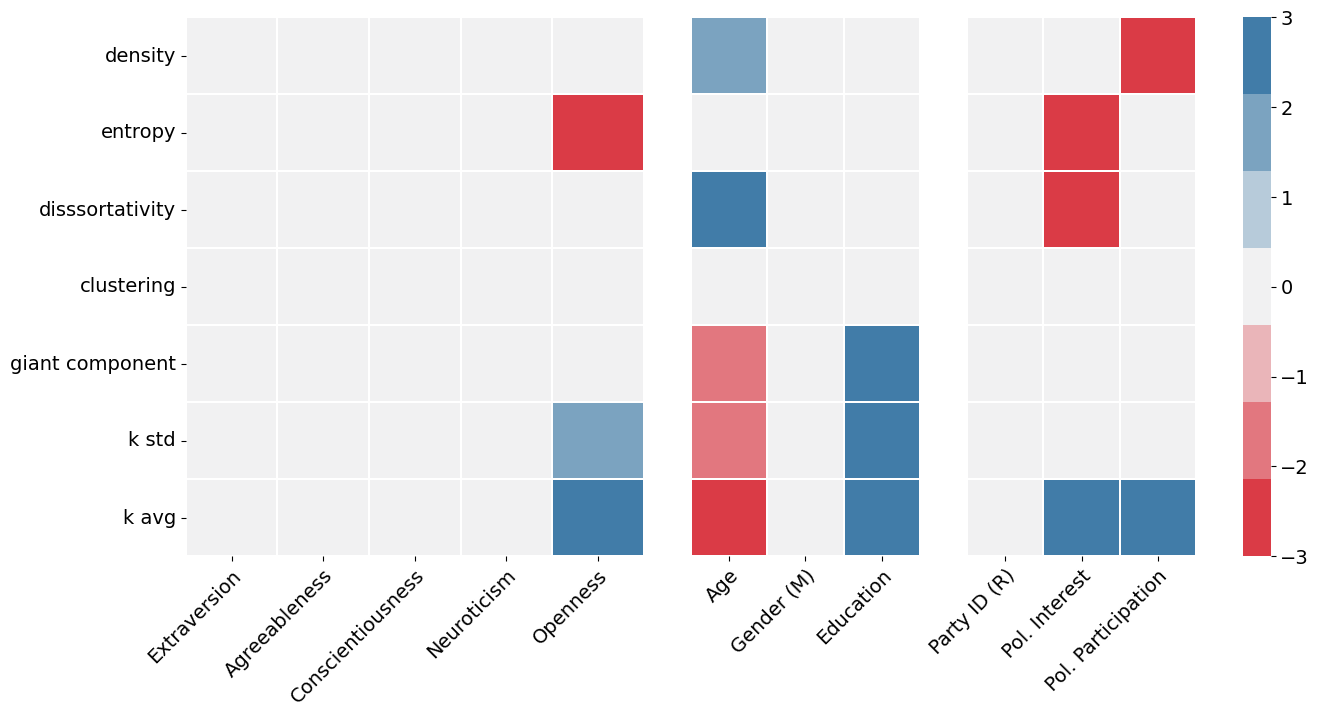

In [9]:
plt.rcParams.update({'font.size': 14})

f, (ax1, ax2, ax3, axcb) = plt.subplots(1, 4,
            gridspec_kw={'width_ratios':[1,.5, .5, 0.06]},
                               figsize=(14, 7))

# ax1.get_shared_y_axes().join(ax2)
ax2.set_ylim(ax1.get_ylim())
ax3.set_ylim(ax1.get_ylim())


g1 = sns.heatmap(masked_corr[personality],
            vmin=-3, vmax=3, 
            cmap=sns.diverging_palette(h_neg=10, h_pos=240, n=7, as_cmap=False, center='light'),
            ax=ax1, linewidths=.01, cbar=False)

g1.set_ylabel('')
g1.set_xlabel('')

g2 = sns.heatmap(masked_corr[demographics],
            vmin=-3, vmax=3, 
            cmap=sns.diverging_palette(h_neg=10, h_pos=240, n=7, as_cmap=False, center='light'),
            ax=ax2, linewidths=.25, cbar=False)

g2.set_ylabel('')
g2.set_xlabel('')
g2.set_yticks([])


g3 = sns.heatmap(masked_corr[politics],
            vmin=-3, vmax=3, 
            cmap=sns.diverging_palette(h_neg=10, h_pos=240, n=7, as_cmap=False, center='light'),
            ax=ax3, linewidths=.25, cbar_ax=axcb)

g3.set_ylabel('')
g3.set_xlabel('')
g3.set_yticks([])

# may be needed to rotate the ticklabels correctly:
for ax in [g1, g2, g3]:
    tl = ax.get_xticklabels()
    for lab in tl:
        lab.set_text(col_dict[lab.get_text()])
        
    ax.set_xticklabels(tl, rotation=45, ha='right', rotation_mode='anchor')
    tly = ax.get_yticklabels()
    ax.set_yticklabels(tly, rotation=0)

plt.savefig('figs/corr.png', dpi=300, bbox_inches='tight')

# Figure 5: Self v. Other network distances

In [ ]:
# load distances
with open('data/distances.json', 'r') as fp:
    distances = json.loads(fp.read())

In [ ]:
# load primary dataset
df = pd.read_csv('data/network_data.csv')

# rename subject_id
df = df.rename(columns={'V160001':'subj_id'})

In [29]:
self_vals = dict()
comp_avg = dict()
comp_high = dict()
comp_low = dict()

samps = 100

for val in ['All','Dem', 'Ind', 'Rep']:
    self_vals.setdefault(val, list())
    comp_avg.setdefault(val, list())
    comp_high.setdefault(val, list())
    comp_low.setdefault(val, list())


for subj, comps in distances.items():
    pid = df[df['subj_id']==int(subj)]['party_id'].values[0]

    if pid == 0:
        party = 'Dem'
    elif pid == 1:
        party = 'Ind'
    elif pid == 2:
        party = 'Rep'

    self = comps['self']
    self = [val for val in self if val > 0]
    
    comp = comps['comp']
    comp = [val for val in comp if val > 0]
    
    if len(self) > 1 and len(comp) > 1:
        ##### self comparison
        n = len(self) # number of comparisons made

        avg = np.mean(self)
        
        if avg == avg:
            self_vals['All'].append(avg)
            self_vals[party].append(avg)
            
        ##### comparison
        avgs = np.zeros(samps)

        for i in range(samps):
            samp = np.random.choice(comp, n)
            avgs[i] = np.mean(samp)

        # add average of average + high and low
        avgs = avgs[~np.isnan(avgs)]
        
        comp_avg['All'].append(np.mean(avgs))
        comp_high['All'].append(np.percentile(avgs, 97.5))
        comp_low['All'].append(np.percentile(avgs, 2.5))
        
        comp_avg[party].append(np.mean(avgs))
        comp_high[party].append(np.percentile(avgs, 97.5))
        comp_low[party].append(np.percentile(avgs, 2.5))
    
print('calculations complete')

calculations complete


In [30]:
def get_cumulative(data, nb, log=False):
    # Find upper and lower bounds
    lower_bound = min(data)
    upper_bound = max(data) + 1

    # define bins
    if log:
        lower_bound = np.log10(lower_bound) if lower_bound > 0 else 0
        upper_bound = np.log10(upper_bound)
        bins = np.logspace(lower_bound, upper_bound, nb)
    else:
        bins = np.linspace(lower_bound, upper_bound, nb)
        
    # compute the midpoint of each bin
    sx = bins[1:] - np.diff(bins) / 2.0          
    
    bin_width = bins[1:] - np.diff(bins)
    
    # compute the height of each bin
    sy, __ = np.histogram(data, bins = bins, density = True)
    
    # From graph above, vector y holds log-binned values of p_1...p_k
    # For cumulative distribution, we want a vector in which:
    # p_1 = p_2 + p_3 + ... + p_k

    bin_width = sy * np.diff(bins)
    cum_sum = np.cumsum(bin_width[::-1]) #sum the reversed p_k distribution

    return sx, cum_sum[::-1] # return the reverse of the cumulative sum

In [31]:
def binning(data,nb=50,log=True):
    # Seperate a vector of data into linear or log bins

    # Input:
    #   data : a vector of data
    #   bins : the number of bins to output (default: 50) 
    #   log : whether to log bin the data (default: True)

    # Output:
    #   x : the the midpoint of each bin
    #   y: the height of each bin 


    # 1. find the data's upper and lower bounds
    lower_bound = min(data)
    upper_bound = max(data) + 1

    # 2. Define bins
    if log:
        lower_bound = np.log10(lower_bound) if lower_bound > 0 else 0
        upper_bound = np.log10(upper_bound)
        bins = np.logspace(lower_bound, upper_bound, nb)

    else:
        bins = np.linspace(lower_bound, upper_bound, nb)
    
    # 3. Compute the midpoint of each bin
    x = bins[1:] - np.diff(bins) / 2.0 

    # 4. Compute the height of each bin
    y, __ = np.histogram(data, bins = bins, density=False)

    # fix numpy density issue
    y = y / np.sum(y)

    return x, y

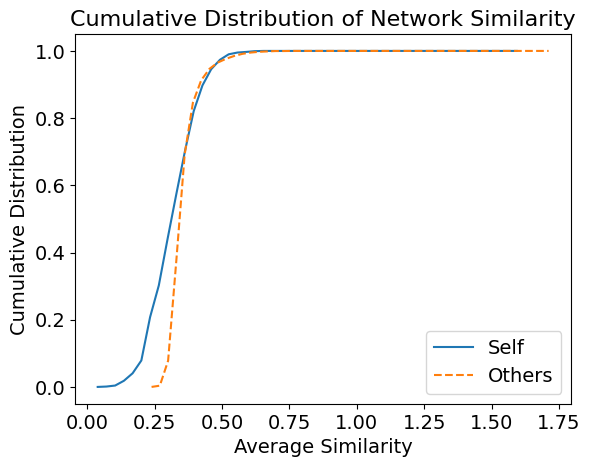

In [33]:
# plot
x, y = get_cumulative(self_vals['All'], nb=50)
y = [1 - num for num in y]
plt.plot(x, y, label='Self')

x, y = get_cumulative(comp_avg['All'], nb=50)
y = [1 - num for num in y]
plt.plot(x, y, ls='--', label='Others')

plt.title('Cumulative Distribution of Network Similarity', size=16)

plt.xlabel('Average Similarity', size=14)
plt.ylabel('Cumulative Distribution', size=14)

plt.legend()

plt.savefig('figs/NetSim_all_cum.png', dpi=300, bbox_inches='tight')
plt.show()

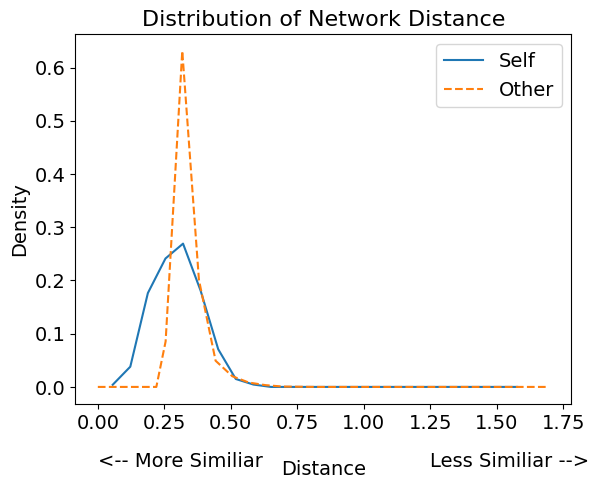

In [34]:
x, y = binning(self_vals['All'], nb=25, log=False)
plt.plot(x,y, label='Self')


x, y = binning(comp_avg['All'], nb=25, log=False)
x = np.insert(x, 0, .22)
x = np.insert(x, 0, 0)

y = np.insert(y, 0, 0)
y = np.insert(y, 0, 0)

plt.plot(x,y, ls='--', label='Other')


plt.text(0, -.15, '<-- More Similiar')
plt.text(1.25, -.15, 'Less Similiar -->')


plt.title(f'Distribution of Network Distance', size=16)

plt.xlabel('\nDistance', size=14)
plt.ylabel('Density', size=14)

plt.legend()
plt.savefig('figs/NetSim.png', dpi=300, bbox_inches='tight')
plt.show()

# t-test calculations for network comparison

In [39]:
for val in ['All','Dem', 'Ind', 'Rep']:
    print(f'Checking {val}...')
    result = sp.ttest_ind(self_vals[val], comp_avg[val]).pvalue
    if result < 0.05:
        print('\tDistributions are significantly different with p=%.5f' % result)
    else:
        print('\tDistributions not significantly different with p=%.3f' % result)

Checking All...
	Distributions are significantly different with p=0.00000
Checking Dem...
	Distributions are significantly different with p=0.00000
Checking Ind...
	Distributions are significantly different with p=0.00000
Checking Rep...
	Distributions are significantly different with p=0.00000


In [40]:
print(f'Comparing Self to low (All)')
result = sp.ttest_ind(self_vals['All'], comp_low['All']).pvalue
if result < 0.05:
    print('\tDistributions are significantly different with p=%.5f' % result)
else:
    print('\tDistributions not significantly different with p=%.3f' % result)

Comparing Self to low (All)
	Distributions are significantly different with p=0.00000


In [41]:
print(f'  Self avg: {np.mean(self_vals["All"])}')
print(f'  Other avg: {np.mean(comp_low["All"])}\n')

  Self avg: 0.2995323837281978
  Other avg: 0.22171318409793064



In [42]:
comp_min = min(comp_avg['All'])
print(comp_min)

0.2235881519422057


In [43]:
### self distances less than comp_min
small = [val for val in self_vals['All'] if val < comp_min]
print(f'{len(small)} ({len(small)/len(self_vals["All"]):.2%}) respondents more self-similar than comp min')

604 (22.52%) respondents more self-similar than comp min


In [44]:
max(comp_avg['All'])

0.7268984662455756

In [45]:
max(self_vals['All'])

0.6095568442821668

In [46]:
for val in ['All','Dem', 'Ind', 'Rep']:
    print(f'Checking {val}...')
    print(f'  Self avg: {np.mean(self_vals[val])}')
    print(f'  Other avg: {np.mean(comp_avg[val])}\n')

Checking All...
  Self avg: 0.2995323837281978
  Other avg: 0.3379969777836687

Checking Dem...
  Self avg: 0.29737295317835855
  Other avg: 0.33710330845895553

Checking Ind...
  Self avg: 0.3012981843597997
  Other avg: 0.3389780666583449

Checking Rep...
  Self avg: 0.299995247245926
  Other avg: 0.33790589101443275



# Appendix: Regression tables

In [9]:
results = pd.read_csv('data/full_results.csv')

In [10]:
# personal measures
measures = personality + demographics + politics

In [11]:
def format_p(p):
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    return f'{p:.3f}{stars}'

In [12]:
doc = Document()

headers = ['Network Stat', 'B', 'SE', '95% CI', 't', 'p']

for measure in measures:
    
    group_df = results[results['measure'] == measure].copy()
    
    # format CI as [low, high]
    group_df['ci'] = group_df.apply(
        lambda r: f'[{r.ci_low:.3f}, {r.ci_high:.3f}]', axis=1)
    
    # format p value with stars
    group_df['p_star'] = group_df['p_value'].apply(format_p)
    
    # sub-table heading
    doc.add_heading(col_dict[measure])
    
    # create table
    table = doc.add_table(rows = 1 + len(group_df), cols = len(headers))
    table.style = 'Table Grid'
    
    # 1. header row
    for i, h in enumerate(headers):
        cell = table.cell(0, i)
        cell.text = h
        run = cell.paragraphs[0].runs[0]
        run.bold = True
    
    # 2. data rows
    display_cols = ['network_stat', 'estimate', 'se', 'ci', 't_stat', 'p_star']
    
    for row_idx, (_, row) in enumerate(group_df.iterrows(), start=1):
        for col_idx, col in enumerate(display_cols):
            val = row[col]
            if col == 'network_stat':
                text = val
            elif col in ['estimate', 'se', 't_stat']:
                text = f'{val:.3f}'
            else:
                text = str(val)
            table.cell(row_idx, col_idx).text = text
    
    # 3. footnote
    note = doc.add_paragraph()
    note.add_run('Note. ').bold = True
    note.add_run('Each row represents a separate regression model predicting the personal characteristic using the network statistic, '
                'controlling for word count and question-level random effects. ')
    note.add_run('B = unstandardized coefficient. CI = confidence interval.')
    note.add_run('* p < .05, ** p < .01, *** p < .001')
    note.style.font.size = Pt(9)
    
    doc.add_paragraph()

doc.save('data/regression_tables.docx')

NameError: name 'results' is not defined